
# CS 430 — Assignment 2: SLCM Regression Analysis

**Course:** CS-430-01 Machine Learning

**Student:** Tudor Iordan

**Objective:** Predict `past_due_rent` using household, income, employment, and housing-related information.

We will compare four regression models:
- Multiple Linear Regression
- Polynomial Regression
- Ridge Regression
- Lasso Regression


In [1]:
# Import the libraries needed for the assignment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone



## 1. Load the dataset and examine its structure

- Load the CSV file into pandas.
- Display the first 5 rows.
- Report the number of rows and columns.
- Print the column names.
- Use `info()` to inspect the dataset.

Answer:
- Which variable will be the target?
- Which columns appear to be numerical?
- Which columns appear to be categorical?


In [2]:
# Load the dataset and display the first five rows
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Assignment 2/SLCM_rent_arrears_student_clean.csv')

df.head()


,record_id,adults_in_household,children_in_household,household_has_65plus,monthly_household_income,income_sources,employment_status,has_housing_voucher,eviction_in_progress,behind_on_utilities,main_reason_behind_on_rent,intake_quarter,monthly_rent,past_due_rent
0,SLCM_0001,1,1,No,293.0,"Food benefits - TANF/SNAP, No income, Other",Unemployed but want to find work,No,I don't know,Yes,Other,2026-Q1,1560.0,3100.0
1,SLCM_0002,0,3,No,2000.0,Child support,Employed,No,I don't know,Yes,Unexpected expense,2026-Q3,1550.0,7300.0
2,SLCM_0003,1,0,No,400.0,Food benefits - TANF/SNAP,Unemployed but want to find work,I don't know,Yes,Yes,Lost a job/had hours cut,2025-Q4,0.0,6000.0
3,SLCM_0004,2,0,No,2500.0,Full-time employment,Unemployed and not looking for work,No,Yes,Yes,Lost a job/had hours cut,2026-Q2,1299.0,2500.0
4,SLCM_0005,1,2,No,14.0,Part-time employment,Employed,No,Yes,No,Unexpected expense,2025-Q4,1105.5,1205.5


In [3]:

# Display the dataset dimensions, column names, and data types
print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()


Shape: (1754, 14)

Column names:
Index(['record_id', 'adults_in_household', 'children_in_household',
       'household_has_65plus', 'monthly_household_income', 'income_sources',
       'employment_status', 'has_housing_voucher', 'eviction_in_progress',
       'behind_on_utilities', 'main_reason_behind_on_rent', 'intake_quarter',
       'monthly_rent', 'past_due_rent'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754 entries, 0 to 1753
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   1754 non-null   object 
 1   adults_in_household         1754 non-null   int64  
 2   children_in_household       1754 non-null   int64  
 3   household_has_65plus        1754 non-null   object 
 4   monthly_household_income    1646 non-null   float64
 5   income_sources              1754 non-null   object 
 6   employment_statu


### Answer

The dataset contains 1,754 rows and 14 columns.

The target variable is `past_due_rent`, which represents the amount of rent owed.

The numerical variables are:
- `adults_in_household`
- `children_in_household`
- `monthly_household_income`
- `monthly_rent`
- `past_due_rent` (target)

The categorical variables are:
- `household_has_65plus`
- `income_sources`
- `employment_status`
- `has_housing_voucher`
- `eviction_in_progress`
- `behind_on_utilities`
- `main_reason_behind_on_rent`
- `intake_quarter`

The `record_id` column is an identifier rather than a meaningful prediction feature.



## 2. Investigate missing values

- Calculate the number of missing values in every column.
- Identify which variables contain missing data.
- Briefly describe how you plan to handle those missing values before modeling.

Do not simply remove all rows with missing data unless you can justify that decision.


In [4]:

# Count the missing values in each column
df.isnull().sum()


,0
record_id,0
adults_in_household,0
children_in_household,0
household_has_65plus,0
monthly_household_income,108
income_sources,0
employment_status,0
has_housing_voucher,0
eviction_in_progress,1
behind_on_utilities,7


In [5]:

# Find all rows containing at least one missing value
missing_rows = df[df.isnull().any(axis=1)]

print("Number of rows with missing values:", len(missing_rows))

# Display the first 20 rows with missing values
display(missing_rows.head(20))


Number of rows with missing values: 137


,record_id,adults_in_household,children_in_household,household_has_65plus,monthly_household_income,income_sources,employment_status,has_housing_voucher,eviction_in_progress,behind_on_utilities,main_reason_behind_on_rent,intake_quarter,monthly_rent,past_due_rent
8,SLCM_0009,4,1,Yes,NaN,"Part-time employment, Veterans benefits, Socia...",Other,No,Yes,No,Other,2026-Q3,400.0,0.00
40,SLCM_0041,2,1,No,1200.0,"Social Security - SSI/SSDI, Food benefits - TA...",Unemployed but want to find work,Yes,Yes,No,NaN,2026-Q1,0.0,0.00
52,SLCM_0053,2,0,No,NaN,"Full-time employment, Other",Employed,No,I don't know,No,Lost a job/had hours cut,2025-Q2,1535.0,1571.96
53,SLCM_0054,2,0,No,NaN,No income,Unemployed but want to find work,No,Yes,No,Lost a job/had hours cut,2024-Q4,1369.0,5218.19
71,SLCM_0072,2,0,No,NaN,"Food benefits - TANF/SNAP, No income",Unemployed but want to find work,No,I don't know,Yes,Lost a job/had hours cut,2025-Q2,944.0,944.00
77,SLCM_0078,1,1,No,NaN,No income,Unemployed but want to find work,No,Yes,Yes,Lost a job/had hours cut,2025-Q1,1250.0,4000.00
115,SLCM_0116,1,2,No,NaN,Food benefits - TANF/SNAP,Unemployed but want to find work,No,Yes,Yes,Have to pay other debt,2025-Q2,130.0,500.00
117,SLCM_0118,0,0,Yes,NaN,"Social Security - SSI/SSDI, Food benefits - TA...",Other,Yes,I don't know,Yes,Other,2026-Q1,459.0,863.00
121,SLCM_0122,3,1,No,NaN,Part-time employment,"Employed, but need more hours and/or different...",No,Yes,No,Lost a job/had hours cut,2025-Q2,1725.0,200.00
138,SLCM_0139,4,2,Yes,5400.0,"Full-time employment, Part-time employment, So...",Other,No,Yes,NaN,Other,2025-Q2,1500.0,6000.00


In [6]:

# Examine households with missing monthly income
missing_income = df[df['monthly_household_income'].isnull()]

display(missing_income[[
    'monthly_household_income',
    'income_sources',
    'employment_status',
    'monthly_rent',
    'past_due_rent'
]].head(20))


,monthly_household_income,income_sources,employment_status,monthly_rent,past_due_rent
8,NaN,"Part-time employment, Veterans benefits, Socia...",Other,400.0,0.00
52,NaN,"Full-time employment, Other",Employed,1535.0,1571.96
53,NaN,No income,Unemployed but want to find work,1369.0,5218.19
71,NaN,"Food benefits - TANF/SNAP, No income",Unemployed but want to find work,944.0,944.00
77,NaN,No income,Unemployed but want to find work,1250.0,4000.00
115,NaN,Food benefits - TANF/SNAP,Unemployed but want to find work,130.0,500.00
117,NaN,"Social Security - SSI/SSDI, Food benefits - TA...",Other,459.0,863.00
121,NaN,Part-time employment,"Employed, but need more hours and/or different...",1725.0,200.00
146,NaN,Full-time employment,Employed,650.0,699.00
151,NaN,"Full-time employment, Food benefits - TANF/SNAP",Unemployed but want to find work,675.0,3000.00


In [7]:

# Display rows where monthly rent is missing
df[df['monthly_rent'].isnull()]


,record_id,adults_in_household,children_in_household,household_has_65plus,monthly_household_income,income_sources,employment_status,has_housing_voucher,eviction_in_progress,behind_on_utilities,main_reason_behind_on_rent,intake_quarter,monthly_rent,past_due_rent
346,SLCM_0347,5,2,No,2000.0,"Part-time employment, Food benefits - TANF/SNAP",Unemployed but want to find work,Yes,I don't know,Yes,Lost a job/had hours cut,2025-Q2,NaN,13600.0
396,SLCM_0397,2,0,No,1200.0,"Full-time employment, No income",Unemployed but want to find work,No,Yes,Yes,Lost a job/had hours cut,2025-Q3,NaN,14000.0
404,SLCM_0405,1,0,No,NaN,"Food benefits - TANF/SNAP, No income",Unemployed but want to find work,No,I don't know,Yes,Lost a job/had hours cut,2025-Q2,NaN,2517.0
459,SLCM_0460,1,0,No,3000.0,Full-time employment,Employed,No,Yes,I don't know,Lost a job/had hours cut,2025-Q2,NaN,3000.0
772,SLCM_0773,2,1,No,2288.0,"Full-time employment, Food benefits - TANF/SNAP",Employed,No,I don't know,No,Other,2025-Q1,NaN,0.0
1166,SLCM_1167,1,0,No,1500.0,Part-time employment,"Employed, but need more hours and/or different...",No,I don't know,No,Lost a job/had hours cut,2026-Q1,NaN,700.0
1206,SLCM_1207,2,0,Yes,2300.0,Social Security - SSI/SSDI,Unemployed but want to find work,No,Yes,Yes,Unexpected expense,2025-Q1,NaN,2800.8
1355,SLCM_1356,2,1,No,0.0,"No income, Other",Unemployed but want to find work,No,I don't know,Yes,Lost a job/had hours cut,2025-Q1,NaN,2400.0


In [8]:

# Investigate income values for households reporting "No income"
no_income = df['income_sources'].str.contains('No income', na=False)

print("Households reporting No income:", no_income.sum())

print("Missing monthly income:",
      df.loc[no_income, 'monthly_household_income'].isna().sum())

print("Zero monthly income:",
      (df.loc[no_income, 'monthly_household_income'] == 0).sum())

print("Positive monthly income:",
      (df.loc[no_income, 'monthly_household_income'] > 0).sum())


Households reporting No income: 533
Missing monthly income: 43
Zero monthly income: 373
Positive monthly income: 117


In [9]:

# Check whether missing-income households report only "No income"
missing_income = df['monthly_household_income'].isna()

print("Missing income with only 'No income':",
      (missing_income & (df['income_sources'] == 'No income')).sum())

print("Missing income with 'No income' plus other sources:",
      (missing_income & no_income &
       (df['income_sources'] != 'No income')).sum())


Missing income with only 'No income': 21
Missing income with 'No income' plus other sources: 22


In [10]:

# Examine reported incomes for households with only "No income"
only_no_income = df[df['income_sources'] == 'No income']

print("Total households:", len(only_no_income))

print("\nMonthly income values:")
print(only_no_income['monthly_household_income'].value_counts(dropna=False))


Total households: 300

Monthly income values:
monthly_household_income
0.000       252
NaN          21
900.000       3
250.000       2
200.000       2
1500.000      2
800.000       2
650.000       2
445.000       1
400.000       1
2000.000      1
1.000         1
288.000       1
4600.000      1
4000.000      1
424.000       1
3200.000      1
2100.000      1
300.000       1
1.035         1
391.000       1
1200.000      1
Name: count, dtype: int64



## 3. Explore the target variable: past_due_rent

Calculate:
- Count
- Mean
- Median
- Standard deviation
- Minimum
- Maximum

Create:
- A histogram
- A boxplot

Answer:
- What does the distribution look like?
- Is the distribution symmetric or skewed?
- Are the mean and median similar?
- Do you notice any unusually high values?
- Why might rent-arrears data naturally contain a wide range of values?


In [11]:
# Calculate descriptive statistics for the target variable
df['past_due_rent'].describe()


,past_due_rent
count,1754.000000
mean,2408.006933
std,2089.515372
min,0.000000
25%,1050.000000
50%,2000.000000
75%,3200.000000
max,20000.000000



### Descriptive Statistics Interpretation

The average past-due rent is $2,408.01, while the median is $2,000. Since the mean is higher than the median, the distribution appears to be right-skewed.

The standard deviation is approximately $2,089.52, indicating considerable variation in the amount of past-due rent.

The values range from $0 to $20,000, with the middle 50% of households owing between $1,050 and $3,200.


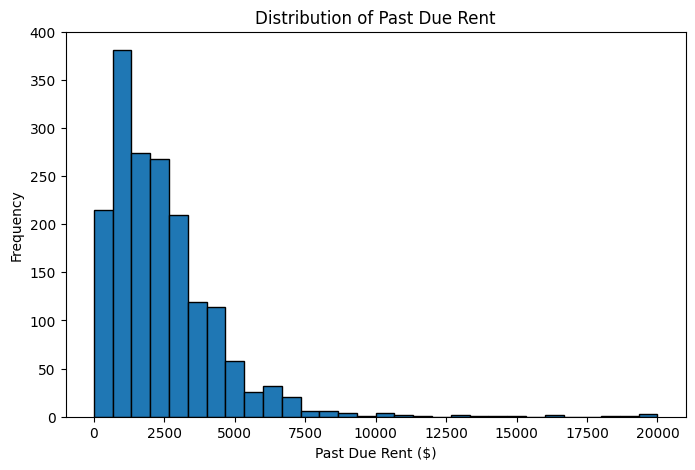

In [12]:

# Plot the distribution of past-due rent
plt.figure(figsize=(8, 5))

plt.hist(df['past_due_rent'], bins=30, edgecolor='black')

plt.xlabel('Past Due Rent ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Past Due Rent')

plt.show()



### Histogram Interpretation

The distribution of past-due rent is right-skewed, with most households owing less than $5,000.

The frequency decreases as the amount of past-due rent increases, creating a long right tail. A small number of households have unusually high amounts of past-due rent, reaching $20,000.

This also explains why the mean ($2,408) is higher than the median ($2,000), since large values pull the mean upward.


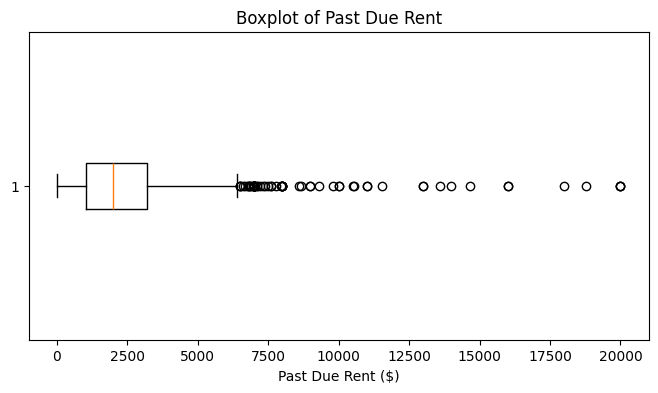

In [13]:

# Create a boxplot to identify the spread and potential outliers
plt.figure(figsize=(8, 4))

plt.boxplot(df['past_due_rent'], vert=False)

plt.xlabel('Past Due Rent ($)')
plt.title('Boxplot of Past Due Rent')

plt.show()



### Boxplot Interpretation

The boxplot confirms that the distribution is right-skewed, with several potential outliers above approximately $6,425.

The median is $2,000, and the middle 50% of households have past-due rent between $1,050 and $3,200.

The maximum value is $20,000, showing that some households have significantly higher rent arrears than others.

This wide range could be explained by differences in monthly rent, household income, and the amount of time households have been behind on payments.

I will keep the outliers because they may represent real financial difficulties rather than incorrect data.



## 4. Create your input features and target

Create X and y using `past_due_rent` as the target.

Do not use `record_id` as an input feature.

Answer:
- Why should `record_id` not be used to predict past-due rent?


In [14]:

# Separate the input features (X) and target variable (y)
X = df.drop(columns=['record_id', 'past_due_rent'])
y = df['past_due_rent']

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()


X shape: (1754, 12)
y shape: (1754,)


,adults_in_household,children_in_household,household_has_65plus,monthly_household_income,income_sources,employment_status,has_housing_voucher,eviction_in_progress,behind_on_utilities,main_reason_behind_on_rent,intake_quarter,monthly_rent
0,1,1,No,293.0,"Food benefits - TANF/SNAP, No income, Other",Unemployed but want to find work,No,I don't know,Yes,Other,2026-Q1,1560.0
1,0,3,No,2000.0,Child support,Employed,No,I don't know,Yes,Unexpected expense,2026-Q3,1550.0
2,1,0,No,400.0,Food benefits - TANF/SNAP,Unemployed but want to find work,I don't know,Yes,Yes,Lost a job/had hours cut,2025-Q4,0.0
3,2,0,No,2500.0,Full-time employment,Unemployed and not looking for work,No,Yes,Yes,Lost a job/had hours cut,2026-Q2,1299.0
4,1,2,No,14.0,Part-time employment,Employed,No,Yes,No,Unexpected expense,2025-Q4,1105.5



### Answer

The input features (X) contain 12 variables describing household, income, employment, and housing characteristics.

The target variable (y) is `past_due_rent`, which represents the amount of rent owed.

The `record_id` column should not be used because it is only a unique identifier and does not provide meaningful information about a household's financial situation. Including it could cause the model to learn irrelevant patterns instead of useful relationships.



## 5. Separate the numerical and categorical features

- Create lists containing numerical features and categorical features.
- Display both lists.
- Briefly explain why machine-learning models require different preparation steps for numerical and categorical variables.


In [15]:

# Separate numerical and categorical input features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['adults_in_household', 'children_in_household', 'monthly_household_income', 'monthly_rent']

Categorical features:
['household_has_65plus', 'income_sources', 'employment_status', 'has_housing_voucher', 'eviction_in_progress', 'behind_on_utilities', 'main_reason_behind_on_rent', 'intake_quarter']



### Answer

The dataset contains 4 numerical features and 8 categorical features.

Numerical features represent quantities, such as household income and monthly rent. These variables may require scaling to make their values comparable.

Categorical features represent categories, such as employment status and housing voucher status. These must be converted into numerical values using encoding because regression models cannot directly process text.

Therefore, numerical and categorical features require different preprocessing steps before training the models.



## 6. Split the data into training and testing sets

Use `test_size=0.20` and `random_state=42`.

- Report the dimensions of X_train, X_test, y_train, and y_test.
- Why should the model be evaluated using data that was not used during training?


In [16]:

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the dimensions of each set
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (1403, 12)
X_test: (351, 12)
y_train: (1403,)
y_test: (351,)



### Answer

The dataset was divided into 80% training data and 20% testing data using `random_state=42`.

- X_train: (1403, 12)
- X_test: (351, 12)
- y_train: (1403,)
- y_test: (351,)

The model should be evaluated on data that was not used during training to determine how well it can predict new observations.

Testing on unseen data helps us identify overfitting and provides a more realistic estimate of the model's performance.



## 7. Prepare the numerical variables

Create an appropriate numerical preprocessing pipeline.

Your pipeline should consider missing values and feature scaling. Use appropriate tools such as SimpleImputer and StandardScaler.

Explain:
- How did you handle missing numerical values?
- Why might feature scaling matter when comparing Linear, Ridge, and Lasso models?


In [17]:

# Create a pipeline to handle missing numerical values and scaling
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numerical_pipeline


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


### Answer

I created a numerical preprocessing pipeline using SimpleImputer and StandardScaler.

For missing numerical values, I will use median imputation because the median is less sensitive to extreme values.

As discussed in Question 2, missing monthly income will first be replaced with $0 when the household reports only "No income". The remaining missing values will be replaced with the median calculated from the training data.

StandardScaler standardizes the numerical features to have a mean of 0 and a standard deviation of 1.

Feature scaling is particularly important for Ridge and Lasso Regression because their regularization penalties are affected by the scale of the features. Scaling makes these penalties more comparable across numerical variables.



## 8. Prepare the categorical variables

Create an appropriate categorical preprocessing pipeline.

Your pipeline should consider missing values and converting text categories into numerical values using SimpleImputer and OneHotEncoder.

Answer:
- Why can regression models not directly use values such as employment categories?
- Why is one-hot encoding appropriate for these variables?
- Why would assigning arbitrary numbers such as 1, 2, 3, and 4 to unordered categories potentially be misleading?


In [18]:

# Create a pipeline to handle missing categorical values and encoding
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

categorical_pipeline


Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='Missing', strategy='constant')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])


### Answer

I created a categorical preprocessing pipeline using SimpleImputer and OneHotEncoder.

Missing categorical values will be replaced with a separate "Missing" category to preserve the observations without making assumptions about their values.

Regression models cannot directly process text categories, such as employment status, because they require numerical inputs.

One-hot encoding converts each category into a separate binary feature (0 or 1). This is appropriate because the categories do not have a natural numerical order.

Assigning arbitrary numbers such as 1, 2, 3, and 4 could be misleading because the model might interpret them as ordered values with meaningful numerical differences.



## 9. Combine your preprocessing steps

Use a ColumnTransformer to combine the numerical and categorical preprocessing.

Your preprocessing should be reusable inside the regression pipelines you create in the next part.

Explain briefly why using a preprocessing pipeline is useful.


In [19]:

# Import FunctionTransformer for custom preprocessing
from sklearn.preprocessing import FunctionTransformer

# Replace missing income with zero when the only income source is "No income"
def fill_zero_income(X):
    X = X.copy()

    condition = (
        X['monthly_household_income'].isna() &
        (X['income_sources'] == 'No income')
    )

    X.loc[condition, 'monthly_household_income'] = 0

    return X


In [20]:

# Combine the numerical and categorical preprocessing pipelines
column_transformer = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Apply the conditional income rule before the other preprocessing steps
preprocessor = Pipeline([
    ('income_rule', FunctionTransformer(fill_zero_income)),
    ('columns', column_transformer)
])

preprocessor


Pipeline(steps=[('income_rule',
                 FunctionTransformer(func=<function fill_zero_income at 0x7c0f1314fce0>)),
                ('columns',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['adults_in_household',
                                                   'children_in_household',
                                                   'monthly_household_income',
                                                   'monthly_rent']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['household_has_65plus',
                                                   'income_sources',
                                                   'employment_status',
                                                   'has_housing_voucher',
                                                   'eviction_in_progress',
                                                   'behind_on_utilities',
                                                   'main_reason_behind_on_rent',
                                                   'intake_quarter'])]))])


### Answer

I combined the numerical and categorical preprocessing pipelines using ColumnTransformer.

Before applying these transformations, I added a custom function to replace missing monthly income with $0 when the only reported income source is "No income".

The numerical pipeline handles the remaining missing values using median imputation and standardizes the features using StandardScaler.

The categorical pipeline replaces missing values with a separate "Missing" category and converts categorical variables into numerical features using OneHotEncoder.

Using a preprocessing pipeline ensures that the same transformations are applied consistently to training and testing data. It also prevents data leakage because imputation and scaling parameters are learned only from the training data.


In [21]:

# Create the Multiple Linear Regression pipeline
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train the model using the training data
linear_pipeline.fit(X_train, y_train)

# Predict past-due rent using the testing data
linear_pred = linear_pipeline.predict(X_test)

# Calculate RMSE and R²
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression RMSE:", round(linear_rmse, 2))
print("Linear Regression R²:", round(linear_r2, 3))


Linear Regression RMSE: 1851.52
Linear Regression R²: 0.164



### Linear Regression Results

The Linear Regression model achieved an RMSE of $1,851.52 and an R² score of 0.164.

The RMSE measures prediction error in dollars, giving more weight to larger errors.

The R² score indicates that the model explains approximately 16.4% of the variation in past-due rent on the testing data.

This suggests that the model has limited predictive accuracy and that other factors not included in the dataset may influence the amount of past-due rent.


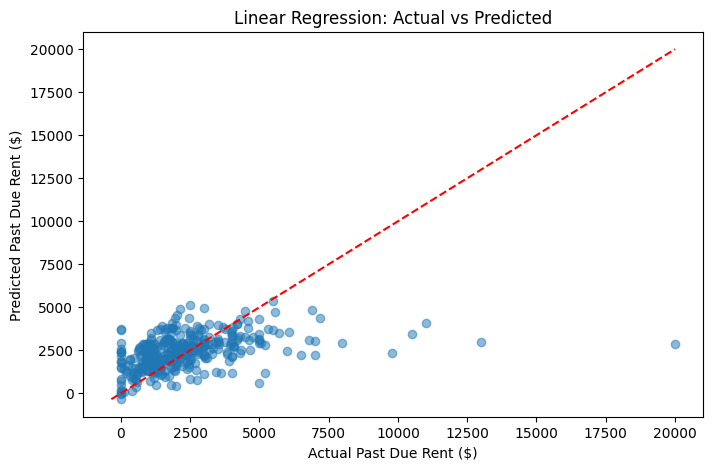

In [22]:

# Plot actual vs predicted past-due rent
plt.figure(figsize=(8, 5))

plt.scatter(y_test, linear_pred, alpha=0.5)

# Add a diagonal line representing perfect predictions
minimum = min(y_test.min(), linear_pred.min())
maximum = max(y_test.max(), linear_pred.max())

plt.plot([minimum, maximum], [minimum, maximum], 'r--')

plt.xlabel('Actual Past Due Rent ($)')
plt.ylabel('Predicted Past Due Rent ($)')
plt.title('Linear Regression: Actual vs Predicted')

plt.show()



### Scatterplot Interpretation

The scatterplot shows that the predictions do not closely follow the diagonal reference line, indicating that the model makes considerable prediction errors.

For households with lower amounts of past-due rent, the model sometimes overestimates or underestimates the actual values.

However, for households with unusually high amounts of past-due rent, the model consistently underestimates the actual values. For example, one household owes approximately $20,000, but the model predicts only around $3,000.

Overall, the model has limited predictive accuracy, especially for households with high rent arrears.



## 11. Build a Polynomial Regression model

Use PolynomialFeatures(degree=2, include_bias=False).

Apply polynomial transformation to the numerical variables only.

Train the model and calculate RMSE and R².

Answer:
- Did Polynomial Regression perform better or worse than Linear Regression?
- What does a degree-2 polynomial allow the model to represent that Linear Regression cannot?
- Why could using a very high polynomial degree lead to overfitting?
- Did making the model more complicated automatically make it better?


In [23]:

# Create a numerical pipeline with polynomial features
polynomial_numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Apply polynomial features only to numerical variables
polynomial_columns = ColumnTransformer([
    ('num', polynomial_numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Include the conditional income rule
polynomial_preprocessor = Pipeline([
    ('income_rule', FunctionTransformer(fill_zero_income)),
    ('columns', polynomial_columns)
])

# Create and train the Polynomial Regression model
polynomial_pipeline = Pipeline([
    ('preprocessor', polynomial_preprocessor),
    ('model', LinearRegression())
])

polynomial_pipeline.fit(X_train, y_train)

# Make predictions and calculate performance
polynomial_pred = polynomial_pipeline.predict(X_test)

polynomial_rmse = np.sqrt(mean_squared_error(y_test, polynomial_pred))
polynomial_r2 = r2_score(y_test, polynomial_pred)

print("Polynomial Regression RMSE:", round(polynomial_rmse, 2))
print("Polynomial Regression R²:", round(polynomial_r2, 3))


Polynomial Regression RMSE: 1863.35
Polynomial Regression R²: 0.153



### Answer

Polynomial Regression performed slightly worse than Linear Regression.

The Polynomial Regression model achieved an RMSE of $1,863.35 and an R² of 0.153, compared to $1,851.52 and 0.164 for Linear Regression.

A degree-2 polynomial allows the model to capture nonlinear relationships by including squared terms and interactions between numerical features.

However, using a very high polynomial degree can lead to overfitting because the model may learn noise and patterns specific to the training data rather than general relationships.

In this case, increasing the model's complexity did not improve its performance on the testing data.



## 12. Build a Ridge Regression model

Create a Ridge Regression pipeline using the same training and testing data.

Choose a reasonable value for alpha. You may experiment with more than one value.

Calculate RMSE and R².

Answer:
- How does Ridge Regression compare with Linear Regression?
- What does regularization do?
- Why can regularization be useful when a model contains many features?


In [24]:

# Create and train the Ridge Regression model
from sklearn.base import clone

ridge_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)

# Make predictions on the testing data
ridge_pred = ridge_pipeline.predict(X_test)

# Calculate RMSE and R²
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression RMSE:", round(ridge_rmse, 2))
print("Ridge Regression R²:", round(ridge_r2, 3))


Ridge Regression RMSE: 1837.55
Ridge Regression R²: 0.176



### Answer

Ridge Regression performed slightly better than Linear Regression.

Ridge achieved an RMSE of $1,837.55 and an R² of 0.176, compared to $1,851.52 and 0.164 for Linear Regression.

Regularization adds a penalty to large coefficients, helping prevent the model from fitting too closely to the training data.

Ridge uses L2 regularization, which reduces the magnitude of coefficients without usually making them exactly zero.

Regularization is useful when a model contains many features because it can reduce overfitting and improve its ability to generalize to unseen data.

In this case, Ridge improved prediction accuracy slightly, although its overall R² remains relatively low.



## 13. Build a Lasso Regression model

Create a Lasso Regression pipeline using the same training and testing data.

Choose a reasonable value for alpha.

Calculate RMSE and R².

Answer:
- How does Lasso compare with Linear and Ridge Regression?
- What is an important difference between Ridge and Lasso?
- What can happen to some coefficients when Lasso is used?


In [25]:

# Create and train the Lasso Regression model
lasso_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', Lasso(alpha=1.0, max_iter=50000))
])

lasso_pipeline.fit(X_train, y_train)

# Make predictions on the testing data
lasso_pred = lasso_pipeline.predict(X_test)

# Calculate RMSE and R²
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression RMSE:", round(lasso_rmse, 2))
print("Lasso Regression R²:", round(lasso_r2, 3))


Lasso Regression RMSE: 1829.02
Lasso Regression R²: 0.184



### Answer

Lasso Regression performed slightly better than both Linear and Ridge Regression.

Lasso achieved an RMSE of $1,829.02 and an R² of 0.184, making it the best-performing model so far.

The main difference between Ridge and Lasso is the type of regularization. Ridge uses L2 regularization, which shrinks coefficients toward zero, while Lasso uses L1 regularization, which can reduce some coefficients to exactly zero.

This means Lasso can effectively eliminate features that contribute little to the model's predictions.

Although Lasso improved performance, its relatively low R² indicates that much of the variation in past-due rent remains unexplained.



## 14. Compare all four models

Create a DataFrame containing the test-set results for all four models, including RMSE and R².

Answer:
- Which model has the lowest RMSE?
- Which model has the highest R²?
- Are the differences between the models large or small?
- Did the most complicated model perform the best?
- Which model would you continue investigating? Explain your choice using evidence from your results.


In [26]:

# Create a DataFrame to compare the four regression models
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'RMSE': [
        linear_rmse,
        polynomial_rmse,
        ridge_rmse,
        lasso_rmse
    ],
    'R²': [
        linear_r2,
        polynomial_r2,
        ridge_r2,
        lasso_r2
    ]
})

# Display the results rounded to three decimal places
comparison.round(3)


,Model,RMSE,R²
0,Linear Regression,1851.518,0.164
1,Polynomial Regression,1863.346,0.153
2,Ridge Regression,1837.549,0.176
3,Lasso Regression,1829.015,0.184



### Answer

Lasso Regression performed the best, achieving the lowest RMSE of $1,829.02 and the highest R² of 0.184.

The differences between the models were relatively small. The RMSE ranged from $1,829.02 to $1,863.35, while the R² ranged from 0.153 to 0.184.

Polynomial Regression was the most complex model in terms of additional features, but it performed worse than the other three models. This shows that increasing model complexity does not automatically improve prediction accuracy.

I would continue investigating Lasso Regression because it achieved the best results and can reduce unnecessary coefficients through regularization.

However, its R² of 0.184 indicates that the model explains only 18.4% of the variation in past-due rent, suggesting that its predictive accuracy is still limited.



## 15. Test your selected model on two hypothetical households

Create two hypothetical households with different characteristics, including household size, monthly income, employment status, housing voucher status, utility situation, and monthly rent.

Use the selected regression pipeline to predict past-due rent for both households.

Answer:
- How are the two households different?
- How different are the predictions?
- Does the difference seem reasonable based on the information provided?


In [27]:

# Create two hypothetical households with different characteristics
new_households = pd.DataFrame([
    {
        'adults_in_household': 1,
        'children_in_household': 0,
        'household_has_65plus': 'No',
        'monthly_household_income': 2800,
        'income_sources': 'Full-time employment',
        'employment_status': 'Employed',
        'has_housing_voucher': 'Yes',
        'eviction_in_progress': "I don't know",
        'behind_on_utilities': 'No',
        'main_reason_behind_on_rent': 'Unexpected expense',
        'intake_quarter': '2026-Q2',
        'monthly_rent': 850
    },
    {
        'adults_in_household': 2,
        'children_in_household': 3,
        'household_has_65plus': 'No',
        'monthly_household_income': 700,
        'income_sources': 'Food benefits - TANF/SNAP',
        'employment_status': 'Unemployed but want to find work',
        'has_housing_voucher': 'No',
        'eviction_in_progress': 'Yes',
        'behind_on_utilities': 'Yes',
        'main_reason_behind_on_rent': 'Lost a job/had hours cut',
        'intake_quarter': '2026-Q2',
        'monthly_rent': 1300
    }
])

# Match the column order used during model training
new_households = new_households[X.columns]

# Display the hypothetical households
new_households


,adults_in_household,children_in_household,household_has_65plus,monthly_household_income,income_sources,employment_status,has_housing_voucher,eviction_in_progress,behind_on_utilities,main_reason_behind_on_rent,intake_quarter,monthly_rent
0,1,0,No,2800,Full-time employment,Employed,Yes,I don't know,No,Unexpected expense,2026-Q2,850
1,2,3,No,700,Food benefits - TANF/SNAP,Unemployed but want to find work,No,Yes,Yes,Lost a job/had hours cut,2026-Q2,1300


In [28]:

# Predict past-due rent for both hypothetical households
new_predictions = lasso_pipeline.predict(new_households)

print("Household 1 predicted past-due rent: $", round(new_predictions[0], 2))
print("Household 2 predicted past-due rent: $", round(new_predictions[1], 2))

# Calculate the difference between the predictions
difference = new_predictions[1] - new_predictions[0]

print("Difference: $", round(difference, 2))


Household 1 predicted past-due rent: $ 1407.56
Household 2 predicted past-due rent: $ 3296.35
Difference: $ 1888.79



### Answer

I used the Lasso Regression model to predict past-due rent for two hypothetical households with different financial and housing characteristics.

Household 1 has one adult, no children, a monthly income of $2,800, and monthly rent of $850. The household is employed, has a housing voucher, and is not behind on utilities.

Household 2 has two adults, three children, a monthly income of $700, and monthly rent of $1,300. The household is unemployed, has no housing voucher, and is behind on utilities.

The model predicted:
- Household 1: $1,407.56
- Household 2: $3,296.35
- Difference: $1,888.79

The difference seems reasonable because Household 2 has a lower income, higher rent, and more financial difficulties.

However, these predictions represent statistical relationships rather than guaranteed outcomes. Since the model has a relatively low R², the predictions should be interpreted with caution.



## 16. What did your models tell you?

Write a short interpretation of your overall results.

Address:
- Which model performed best on the test data?
- Approximately how large are the model's typical prediction errors?
- Did Polynomial Regression provide a meaningful improvement?
- Did regularization improve the results?
- What does your model appear able to predict reasonably well?
- Where does it appear to struggle?



### Answer

Lasso Regression performed best on the testing data, achieving an RMSE of $1,829.02 and an R² of 0.184.

The RMSE indicates that the model makes substantial prediction errors, while the R² shows that it explains only 18.4% of the variation in past-due rent.

Polynomial Regression did not improve performance. Its RMSE was higher than Linear Regression, suggesting that the additional polynomial features were not beneficial.

Regularization slightly improved the results, as both Ridge and Lasso performed better than ordinary Linear Regression.

Based on the Actual vs. Predicted scatterplot, the Linear Regression model produces predictions mostly within the more common range of past-due rent values. However, it struggles with unusually high amounts, which it tends to underestimate.

The hypothetical household predictions also demonstrate how the selected Lasso model produces different estimates based on household characteristics.

Overall, the models identified some useful patterns, but their relatively low R² scores suggest that the available features are insufficient for highly accurate predictions.



## 17. What is your overall finding for SLCM?

### Answer

The goal of this analysis was to predict how much past-due rent a household might have based on information such as household size, income, employment status, and housing conditions.

I compared four regression models, and Lasso Regression performed the best, although its prediction accuracy was still limited.

The model achieved an RMSE of approximately $1,829 and an R² of 0.184, meaning it explained only 18.4% of the differences in past-due rent.

One important finding is that more complex models do not necessarily produce better predictions, since Polynomial Regression performed worse than Linear Regression.

The results also suggest that the available household and financial information can help identify general patterns, but it is not enough to accurately predict rent arrears for every household.

This type of analysis could help SLCM better understand community housing needs and identify areas that deserve further investigation.

However, the model struggles with unusually high amounts of past-due rent, so its predictions should not be used alone to make decisions about individual households.
